# Notebook 08: 樹種不変特徴設計で現行ベスト(RMSE=20.19%)に挑む

診断スクリプトの結論を全て前提に、特徴設計でRMSEを下げる。  
**ルール:** 全実験 = 樹種GroupKFold / 元スケールRMSE / log1p不使用 / fitはfold内学習側のみ  
**基準:** 全波数 + RF(SNV+SG1, raw-y) = **RMSE 20.19%**

In [1]:
import sys, os
sys.path.insert(0, '../src')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import GroupKFold
from sklearn.cross_decomposition import PLSRegression
from sklearn.ensemble import (RandomForestRegressor, ExtraTreesRegressor,
                               HistGradientBoostingRegressor)
from sklearn.linear_model import LinearRegression

from preprocessing import snv, savitzky_golay
from utils import setup_japanese_font, rmse

setup_japanese_font()
np.random.seed(42)
SEED = 42

# Data
df = pd.read_csv('../data/train.csv', encoding='cp932')
META = ['sample number', 'species number', '樹種', '含水率']
wn     = df.columns.drop(META).astype(float).values          # (1555,)
X_raw  = df.drop(columns=META).values.astype(float)          # (1322,1555)
y      = df['含水率'].values.astype(float)
groups = df['species number'].values

# Shared GroupKFold splits
gkf    = GroupKFold(n_splits=5)
SPLITS = list(gkf.split(X_raw, y, groups))
fold_sp = [sorted(set(groups[va])) for _, va in SPLITS]
print('Fold validation species:')
for i, sps in enumerate(fold_sp):
    print(f'  Fold{i+1}: {sps}')

# Preprocessing
def preproc(X):
    return savitzky_golay(snv(X), window_length=11, polyorder=2, deriv=1)

X_pp  = preproc(X_raw)    # SNV+SG1
X_snv = snv(X_raw)        # SNV only

# Helpers
def corr_vec(X, yv):
    yc = yv - yv.mean(); Xc = X - X.mean(axis=0)
    num = (Xc * yc[:, None]).sum(0)
    den = np.sqrt((Xc**2).sum(0) * (yc**2).sum())
    with np.errstate(invalid='ignore', divide='ignore'):
        return np.where(den > 0, num / den, 0.0)

def band_mask(center, hw=75):
    return (wn >= center - hw) & (wn <= center + hw)

RF_KW = dict(n_estimators=300, max_features=0.3, random_state=SEED, n_jobs=-1)

BASELINE_MEAN  = 20.19
BASELINE_FOLDS = [17.2, 14.2, 42.5, 16.0, 11.1]

def row(name, n_feat, fr):
    fr = list(fr)
    return {'name': name, 'n_feat': int(n_feat),
            'mean': round(float(np.nanmean(fr)), 2),
            'std':  round(float(np.nanstd(fr)), 2),
            'F1': round(fr[0],2), 'F2': round(fr[1],2), 'F3': round(fr[2],2),
            'F4': round(fr[3],2), 'F5': round(fr[4],2),
            'diff': round(float(np.nanmean(fr)) - BASELINE_MEAN, 2)}

ROWS = [row('Baseline all-wn RF', 1555, BASELINE_FOLDS)]
print(f'\nBaseline: {BASELINE_MEAN}% +/- {np.std(BASELINE_FOLDS):.2f}  Folds: {BASELINE_FOLDS}')

Fold validation species:
  Fold1: [np.int64(11), np.int64(12)]
  Fold2: [np.int64(5), np.int64(14)]
  Fold3: [np.int64(15), np.int64(17), np.int64(19)]
  Fold4: [np.int64(1), np.int64(3), np.int64(4)]
  Fold5: [np.int64(8), np.int64(13), np.int64(16)]

Baseline: 20.19% +/- 11.34  Folds: [17.2, 14.2, 42.5, 16.0, 11.1]


## 実験1: 樹種間一貫性ベースの波数選択

各fold内で「訓練側の各樹種ごとにr(含水率 vs 波数)を計算し、
**符号一致率 >= sign_thresh かつ 樹種間r_std <= std_thresh** の波数だけを残す」。  
グリッド: sign_thresh in {0.8,0.9,1.0} × std_thresh in {0.20,0.10,0.05}  
**feature selection の計算はfold内訓練側のみ（リーク厳禁）**

In [2]:
def fold_select_rf(sign_thresh, std_thresh):
    """
    Fold-internal wavenumber selection: computed from training side only.
    Returns (fold_rmses, avg_n_selected_per_fold).
    """
    fold_r, n_sel = [], []
    for tr, va in SPLITS:
        Xtr = preproc(X_raw[tr]); Xva = preproc(X_raw[va])
        ytr, yva = y[tr], y[va]; gtr = groups[tr]

        # Per-wavenumber r for each TRAINING species
        r_list = [corr_vec(Xtr[gtr == sp], ytr[gtr == sp])
                  for sp in sorted(set(gtr)) if (gtr == sp).sum() >= 3]
        r_mat   = np.array(r_list)                   # (n_sp, 1555)
        sc      = np.abs(np.sign(r_mat).sum(0)) / len(r_list)
        rs      = r_mat.std(0)
        sel     = (sc >= sign_thresh) & (rs <= std_thresh)

        n_sel.append(int(sel.sum()))
        if sel.sum() == 0:
            fold_r.append(np.nan); continue

        rf = RandomForestRegressor(**RF_KW)
        rf.fit(Xtr[:, sel], ytr)
        fold_r.append(rmse(yva, rf.predict(Xva[:, sel])))
    return fold_r, int(np.mean(n_sel))


# Grid search
thresholds = [(s, d) for s in [0.8, 0.9, 1.0] for d in [0.20, 0.10, 0.05]]
exp1_results = []

print(f"{'sign':>5} {'std':>5} {'N_wn':>6} {'mean':>7} {'F1':>6} {'F2':>6} {'F3(hard)':>8} {'F4':>6} {'F5':>6} {'vs_base':>8}")
print('-'*70)
for st, dt in thresholds:
    fr, n = fold_select_rf(st, dt)
    r = row(f'sign>={st}/std<={dt} RF', n, fr)
    exp1_results.append((st, dt, fr, n, r))
    ROWS.append(r)
    print(f'{st:>5.1f} {dt:>5.2f} {n:>6d} {r["mean"]:>7.2f} {r["F1"]:>6.2f} '
          f'{r["F2"]:>6.2f} {r["F3"]:>8.2f} {r["F4"]:>6.2f} {r["F5"]:>6.2f} {r["diff"]:>+8.2f}')

 sign   std   N_wn    mean     F1     F2 F3(hard)     F4     F5  vs_base
----------------------------------------------------------------------


  0.8  0.20    763   19.59  16.59  14.47    41.37  16.45   9.05    -0.60


  0.8  0.10    613   18.85  16.17  14.08    40.45  14.57   8.96    -1.34


  0.8  0.05    405   18.49  15.50  13.71    40.89  12.94   9.41    -1.70


  0.9  0.20    762   19.38  16.45  14.23    40.67  16.45   9.08    -0.81


  0.9  0.10    613   18.85  16.17  14.08    40.45  14.57   8.96    -1.34


  0.9  0.05    405   18.49  15.50  13.71    40.89  12.94   9.41    -1.70


  1.0  0.20    762   19.38  16.45  14.23    40.67  16.45   9.08    -0.81


  1.0  0.10    613   18.85  16.17  14.08    40.45  14.57   8.96    -1.34


  1.0  0.05    405   18.49  15.50  13.71    40.89  12.94   9.41    -1.70


Best: sign>=0.8, std<=0.05  RMSE=18.49% (vs baseline: -1.70pp)  n_wn=405
Fold RMSE: [15.5, 13.71, 40.89, 12.94, 9.41]


  6900 cm^-1 selection freq: 0.00
  5200 cm^-1 selection freq: 0.00
  4760 cm^-1 selection freq: 1.00


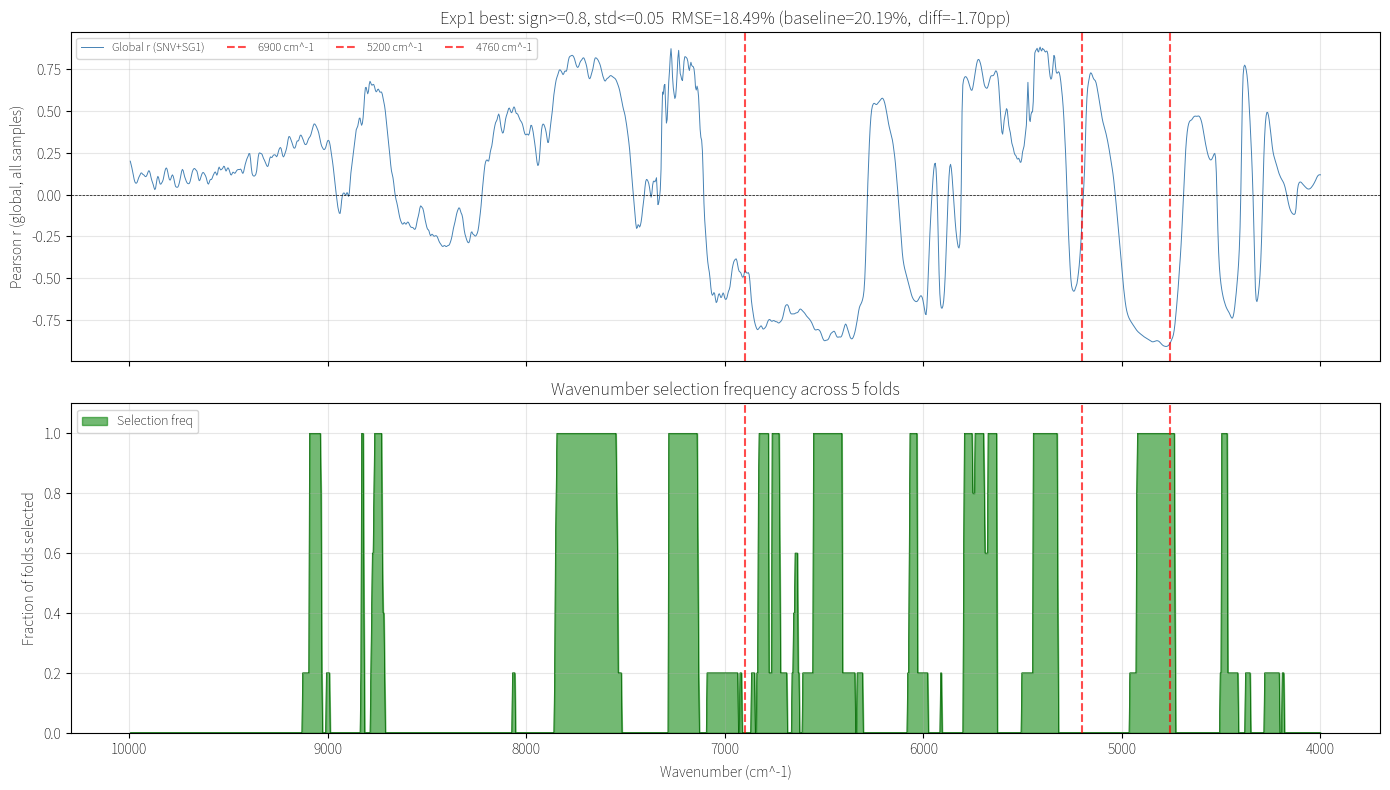

In [3]:
# Best threshold
best_idx = int(np.argmin([r_["mean"] for *_, r_ in exp1_results]))
best_st, best_dt, best_fr, best_n, best_r = exp1_results[best_idx]
print(f"Best: sign>={best_st}, std<={best_dt}  "
      f"RMSE={best_r['mean']:.2f}% (vs baseline: {best_r['diff']:+.2f}pp)  n_wn={best_n}")
print(f"Fold RMSE: {[best_r['F1'], best_r['F2'], best_r['F3'], best_r['F4'], best_r['F5']]}")

# Compute selection frequency across 5 folds for best threshold
sel_list = []
for tr, va in SPLITS:
    Xtr = preproc(X_raw[tr]); ytr = y[tr]; gtr = groups[tr]
    r_list = [corr_vec(Xtr[gtr == sp], ytr[gtr == sp])
              for sp in sorted(set(gtr)) if (gtr == sp).sum() >= 3]
    r_mat = np.array(r_list)
    sc = np.abs(np.sign(r_mat).sum(0)) / len(r_list)
    rs = r_mat.std(0)
    sel_list.append(((sc >= best_st) & (rs <= best_dt)).astype(float))

sel_freq = np.mean(sel_list, axis=0)   # 0-1: fraction of folds selecting each wavenumber

# Check O-H bands
for band_name, bwn in [('6900', 6900), ('5200', 5200), ('4760', 4760)]:
    idx = np.argmin(np.abs(wn - bwn))
    print(f"  {band_name} cm^-1 selection freq: {sel_freq[idx]:.2f}")

# Plot
fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)
r_global = corr_vec(X_pp, y)
axes[0].plot(wn, r_global, 'steelblue', lw=0.7, label='Global r (SNV+SG1)')
axes[0].axhline(0, color='k', lw=0.5, ls='--')
axes[0].set_ylabel('Pearson r (global, all samples)')
axes[0].set_title(f'Exp1 best: sign>={best_st}, std<={best_dt}  RMSE={best_r["mean"]:.2f}% '
                  f'(baseline=20.19%,  diff={best_r["diff"]:+.2f}pp)')
for bname, bwn_ in [('6900', 6900), ('5200', 5200), ('4760', 4760)]:
    axes[0].axvline(bwn_, color='red', lw=1.5, ls='--', alpha=0.7, label=f'{bname} cm^-1')
axes[0].legend(loc='upper left', fontsize=8, ncol=4)
axes[0].grid(True, alpha=0.3)

axes[1].fill_between(wn, sel_freq, alpha=0.55, color='green', label='Selection freq')
axes[1].plot(wn, sel_freq, 'darkgreen', lw=0.5)
axes[1].set_ylim(0, 1.1)
axes[1].set_ylabel('Fraction of folds selected')
axes[1].set_title('Wavenumber selection frequency across 5 folds')
for bname, bwn_ in [('6900', 6900), ('5200', 5200), ('4760', 4760)]:
    axes[1].axvline(bwn_, color='red', lw=1.5, ls='--', alpha=0.7)
axes[1].legend(loc='upper left', fontsize=9)
axes[1].grid(True, alpha=0.3)

axes[1].set_xlabel('Wavenumber (cm^-1)')
axes[1].invert_xaxis()
plt.tight_layout()
plt.savefig('../results/exp1_selected_wavenumbers.png', dpi=150, bbox_inches='tight')
plt.show()

## 実験2: 水のO-H帯ピンポイント特徴

物理に基づく少数特徴の実力確認。  
- 特徴: SNVスペクトルの帯平均 + SNV+SG1微分の帯平均 (各帯域 ±75 cm^-1)  
- 4760のみ → +6900 → +SG1微分値 → 5200を加えると悪化するかを検証  
- 帯域内の全波数列を使うバリアントも試す

In [4]:
def cv_band_means_rf(centers_snv=(), centers_sg1=(), hw=75):
    """
    SNVスペクトル帯平均 + SNV+SG1帯平均 を特徴化してRF。
    前処理はfold内で独立実施。
    """
    fold_r = []
    for tr, va in SPLITS:
        Xtr_s = snv(X_raw[tr]);       Xva_s = snv(X_raw[va])
        Xtr_g = preproc(X_raw[tr]);   Xva_g = preproc(X_raw[va])
        parts_tr, parts_va = [], []
        for c in centers_snv:
            parts_tr.append(Xtr_s[:, band_mask(c, hw)].mean(1, keepdims=True))
            parts_va.append(Xva_s[:, band_mask(c, hw)].mean(1, keepdims=True))
        for c in centers_sg1:
            parts_tr.append(Xtr_g[:, band_mask(c, hw)].mean(1, keepdims=True))
            parts_va.append(Xva_g[:, band_mask(c, hw)].mean(1, keepdims=True))
        Ftr = np.hstack(parts_tr); Fva = np.hstack(parts_va)
        m = RandomForestRegressor(**RF_KW)
        m.fit(Ftr, y[tr])
        fold_r.append(rmse(y[va], m.predict(Fva)))
    return fold_r

def cv_band_cols_rf(centers, hw=75):
    """帯域内の全列をそのまま特徴量として使う。"""
    mask = np.zeros(len(wn), bool)
    for c in centers: mask |= band_mask(c, hw)
    fold_r = []
    for tr, va in SPLITS:
        Xtr = preproc(X_raw[tr]); Xva = preproc(X_raw[va])
        m = RandomForestRegressor(**RF_KW)
        m.fit(Xtr[:, mask], y[tr])
        fold_r.append(rmse(y[va], m.predict(Xva[:, mask])))
    return fold_r, int(mask.sum())

configs = [
    # name,                       centers_snv,         centers_sg1,  hw
    ('4760 mean(SNV)',             [4760],              [],           75),
    ('6900 mean(SNV)',             [6900],              [],           75),
    ('4760+6900 mean(SNV)',        [4760, 6900],        [],           75),
    ('4760+6900 mean(SG1)',        [],                  [4760, 6900], 75),
    ('4760+6900 SNV+SG1 both',    [4760, 6900],        [4760, 6900], 75),
    # 5200を追加したら悪化するか？
    ('4760+6900+5200 SNV',        [4760, 6900, 5200],  [],           75),
    ('4760+6900+5200 SNV+SG1',    [4760, 6900, 5200],  [4760, 6900, 5200], 75),
]

print(f"{'特徴セット':<35} {'N':>5} {'mean':>7} {'std':>6} {'F1':>6} {'F2':>6} {'F3':>6} {'F4':>6} {'F5':>6} {'diff':>7}")
print('-'*95)
for name, cs, cg, hw in configs:
    n = len(cs) + len(cg)
    fr = cv_band_means_rf(cs, cg, hw)
    r  = row(f'[E2] {name}', n, fr)
    ROWS.append(r)
    print(f'{name:<35} {n:>5d} {r["mean"]:>7.2f} {r["std"]:>6.2f} {r["F1"]:>6.2f} '
          f'{r["F2"]:>6.2f} {r["F3"]:>6.2f} {r["F4"]:>6.2f} {r["F5"]:>6.2f} {r["diff"]:>+7.2f}')

print()
print('--- 帯域内全列 (SNV+SG1) ---')
for centers, label in [([4760], '4760 cols'), ([4760,6900], '4760+6900 cols'),
                        ([4760,6900,5200], '4760+6900+5200 cols')]:
    fr, n_c = cv_band_cols_rf(centers)
    r = row(f'[E2c] {label}', n_c, fr)
    ROWS.append(r)
    print(f'{label:<35} {n_c:>5d} {r["mean"]:>7.2f} {r["std"]:>6.2f} {r["F1"]:>6.2f} '
          f'{r["F2"]:>6.2f} {r["F3"]:>6.2f} {r["F4"]:>6.2f} {r["F5"]:>6.2f} {r["diff"]:>+7.2f}')

特徴セット                                   N    mean    std     F1     F2     F3     F4     F5    diff
-----------------------------------------------------------------------------------------------


4760 mean(SNV)                          1   40.14  18.10  39.25  24.75  75.08  29.14  32.51  +19.95


6900 mean(SNV)                          1   31.00   8.03  27.79  23.91  46.72  28.68  27.89  +10.81


4760+6900 mean(SNV)                     2   30.49  10.76  32.81  21.16  50.46  22.59  25.44  +10.30


4760+6900 mean(SG1)                     2   22.77   8.69  20.88  23.56  38.40  18.93  12.09   +2.58


...

4760+6900+5200 SNV                      3   29.01  11.49  29.95  18.98  50.26  18.85  27.02   +8.82


4760+6900+5200 SNV+SG1                  6   23.08  11.68  23.41  21.43  44.72  14.32  11.51   +2.89

--- 帯域内全列 (SNV+SG1) ---


4760 cols                              39   18.92   9.84  14.47  11.71  38.36  13.48  16.60   -1.27


4760+6900 cols                         78   19.01  10.26  15.19  10.55  38.80  18.39  12.12   -1.18


4760+6900+5200 cols                   117   20.30   9.75  16.21  15.52  39.22  18.97  11.56   +0.11


## 実験3: バンド比特徴（樹種差を分母で相殺）

水のO-H帯 / 安定参照帯 の比・差特徴で「樹種ベースライン変動」を除去できるかを検証。  
診断で `5200−9000 diff` が r=0.61 と高相関だったのでこの差特徴も含む。  
線形回帰 (単特徴診断) と RF (非線形) の両方で評価する。

In [5]:
def get_ratio_feats(Xs, Xg, hw=75):
    """SNVスペクトルXs, SNV+SG1スペクトルXg からバンド比/差特徴を返す。"""
    a4760 = Xs[:, band_mask(4760, hw)].mean(1)
    a5200 = Xs[:, band_mask(5200, hw)].mean(1)
    a6900 = Xs[:, band_mask(6900, hw)].mean(1)
    a9000 = Xs[:, band_mask(9000, hw)].mean(1)
    a8000 = Xs[:, band_mask(8000, hw)].mean(1)
    d4760 = Xg[:, band_mask(4760, hw)].mean(1)
    d6900 = Xg[:, band_mask(6900, hw)].mean(1)
    return {
        '4760/9000':        a4760 / (a9000 + 1e-9),
        '6900/9000':        a6900 / (a9000 + 1e-9),
        '5200/9000':        a5200 / (a9000 + 1e-9),
        '5200-9000':        a5200 - a9000,             # r=0.61 from diagnosis
        '4760-9000':        a4760 - a9000,
        '4760/8000':        a4760 / (a8000 + 1e-9),
        '(4760+6900)/9000': (a4760 + a6900) / (2*(a9000 + 1e-9)),
        'SG1_4760':         d4760,
        'SG1_6900':         d6900,
    }

feat_names_all = ['4760/9000','6900/9000','5200/9000','5200-9000','4760-9000',
                  '4760/8000','(4760+6900)/9000','SG1_4760','SG1_6900']

# (a) 線形回帰で各特徴の素の実力確認
print('--- 単特徴 / 線形回帰 ---')
for fn in feat_names_all:
    fold_r = []
    for tr, va in SPLITS:
        Xs_tr = snv(X_raw[tr]);    Xs_va = snv(X_raw[va])
        Xg_tr = preproc(X_raw[tr]); Xg_va = preproc(X_raw[va])
        ftr = get_ratio_feats(Xs_tr, Xg_tr)[fn].reshape(-1,1)
        fva = get_ratio_feats(Xs_va, Xg_va)[fn].reshape(-1,1)
        m = LinearRegression().fit(ftr, y[tr])
        fold_r.append(rmse(y[va], m.predict(fva)))
    r_val = np.corrcoef(get_ratio_feats(X_snv, X_pp)[fn], y)[0,1]
    print(f'  {fn:<22}: r={r_val:+.3f}  RMSE={np.nanmean(fold_r):.2f}+/-{np.nanstd(fold_r):.2f}')

# (b) RF でバンド比の組み合わせ
def cv_ratio_rf(fnames):
    fold_r = []
    for tr, va in SPLITS:
        Xs_tr = snv(X_raw[tr]);    Xs_va = snv(X_raw[va])
        Xg_tr = preproc(X_raw[tr]); Xg_va = preproc(X_raw[va])
        Ftr = np.column_stack([get_ratio_feats(Xs_tr, Xg_tr)[f] for f in fnames])
        Fva = np.column_stack([get_ratio_feats(Xs_va, Xg_va)[f] for f in fnames])
        m = RandomForestRegressor(**RF_KW)
        m.fit(Ftr, y[tr])
        fold_r.append(rmse(y[va], m.predict(Fva)))
    return fold_r

print()
print('--- バンド比 / RF ---')
ratio_combos = [
    ('4760/9000',             ['4760/9000']),
    ('5200-9000(best_linreg)',['5200-9000']),
    ('4760-9000',             ['4760-9000']),
    ('4760+6900 /9000',       ['4760/9000','6900/9000']),
    ('4760/9000+5200-9000',   ['4760/9000','5200-9000']),
    ('all ratio',             feat_names_all),
]
for name, fnames in ratio_combos:
    fr = cv_ratio_rf(fnames)
    r  = row(f'[E3] {name}', len(fnames), fr)
    ROWS.append(r)
    print(f'  {name:<28}: RMSE={r["mean"]:.2f}+/-{r["std"]:.2f}'
          f'  F3={r["F3"]:.2f}  diff={r["diff"]:+.2f}')

# (c) 帯域全列 + バンド比差特徴の組み合わせ
def cv_cols_plus_ratio(centers, ratio_fnames, hw=75):
    mask = np.zeros(len(wn), bool)
    for c in centers: mask |= band_mask(c, hw)
    fold_r = []
    for tr, va in SPLITS:
        Xs_tr = snv(X_raw[tr]);    Xs_va = snv(X_raw[va])
        Xg_tr = preproc(X_raw[tr]); Xg_va = preproc(X_raw[va])
        rtr = get_ratio_feats(Xs_tr, Xg_tr); rva = get_ratio_feats(Xs_va, Xg_va)
        Ftr = np.hstack([Xg_tr[:, mask], np.column_stack([rtr[f] for f in ratio_fnames])])
        Fva = np.hstack([Xg_va[:, mask], np.column_stack([rva[f] for f in ratio_fnames])])
        m = RandomForestRegressor(**RF_KW)
        m.fit(Ftr, y[tr])
        fold_r.append(rmse(y[va], m.predict(Fva)))
    return fold_r, int(mask.sum()) + len(ratio_fnames)

print()
print('--- 帯域全列 + バンド比/差の複合 ---')
combos_c = [
    ('4760+6900 cols + 5200-9000', [4760,6900], ['5200-9000']),
    ('4760+6900 cols + diff+ratio',  [4760,6900], ['4760-9000','5200-9000','4760/9000']),
]
for name, centers, rfnames in combos_c:
    fr, n = cv_cols_plus_ratio(centers, rfnames)
    r = row(f'[E3c] {name}', n, fr)
    ROWS.append(r)
    print(f'  {name:<38}: RMSE={r["mean"]:.2f}+/-{r["std"]:.2f}  F3={r["F3"]:.2f}  diff={r["diff"]:+.2f}')

--- 単特徴 / 線形回帰 ---


  4760/9000             : r=+0.650  RMSE=51.18+/-25.44


  6900/9000             : r=-0.742  RMSE=33.57+/-20.65


  5200/9000             : r=-0.462  RMSE=46.32+/-14.15


  5200-9000             : r=+0.546  RMSE=49.54+/-27.71


...

  4760+6900 /9000             : RMSE=27.89+/-9.96  F3=46.96  diff=+7.70


  4760/9000+5200-9000         : RMSE=30.15+/-8.41  F3=46.06  diff=+9.96


  all ratio                   : RMSE=23.25+/-11.86  F3=45.81  diff=+3.06

--- 帯域全列 + バンド比/差の複合 ---


  4760+6900 cols + 5200-9000            : RMSE=18.89+/-10.37  F3=38.90  diff=-1.30


  4760+6900 cols + diff+ratio           : RMSE=18.85+/-10.43  F3=39.11  diff=-1.34


## 実験4: 最良特徴 × モデル比較

実験1〜3の最良特徴セット(fold-internal選択)に対してモデルだけを振る。  
- RandomForest (基準), ExtraTrees, HistGradientBoosting  
- PLSRegression: fold内3-fold inner CVでn_componentsを最適化  
  診断では全波数でn=2が最良だった → 特徴削減後は何成分が最適か確認

In [6]:
# Re-derive best exp1 threshold (sign_thresh, std_thresh)
best_mean_val = min(r_["mean"] for *_, r_ in exp1_results)
best_st = best_dt = None
for _st, _dt, _fr, _n, _r in exp1_results:
    if _r["mean"] == best_mean_val:
        best_st, best_dt = _st, _dt
        break
print(f"Exp4 feature selection: sign>={best_st}, std<={best_dt}  (RMSE={best_mean_val:.2f}%)")

models_exp4 = [
    ('RF (baseline model)',  lambda: RandomForestRegressor(**RF_KW)),
    ('ExtraTrees',           lambda: ExtraTreesRegressor(n_estimators=300, max_features=0.3,
                                                          random_state=SEED, n_jobs=-1)),
    ('HistGradientBoosting', lambda: HistGradientBoostingRegressor(max_iter=300,
                                                                    random_state=SEED)),
]

print(f"\n{'Model':<25} {'N_wn':>6} {'mean':>7} {'std':>6} {'F1':>6} {'F2':>6} {'F3':>6} {'F4':>6} {'F5':>6} {'diff':>7}")
print('-'*85)

for name, model_fn in models_exp4:
    fold_r, n_list = [], []
    for tr, va in SPLITS:
        Xtr = preproc(X_raw[tr]); Xva = preproc(X_raw[va])
        ytr, yva = y[tr], y[va]; gtr = groups[tr]
        r_list = [corr_vec(Xtr[gtr == sp], ytr[gtr == sp])
                  for sp in sorted(set(gtr)) if (gtr == sp).sum() >= 3]
        r_mat = np.array(r_list)
        sc = np.abs(np.sign(r_mat).sum(0)) / len(r_list)
        rs = r_mat.std(0)
        sel = (sc >= best_st) & (rs <= best_dt)
        n_list.append(int(sel.sum()))
        if sel.sum() == 0: fold_r.append(np.nan); continue
        m = model_fn()
        m.fit(Xtr[:, sel], ytr)
        fold_r.append(rmse(yva, m.predict(Xva[:, sel])))
    avg_n = int(np.mean(n_list))
    r = row(f'[E4] {name}', avg_n, fold_r)
    ROWS.append(r)
    print(f'{name:<25} {avg_n:>6d} {r["mean"]:>7.2f} {r["std"]:>6.2f} '
          f'{r["F1"]:>6.2f} {r["F2"]:>6.2f} {r["F3"]:>6.2f} {r["F4"]:>6.2f} {r["F5"]:>6.2f} {r["diff"]:>+7.2f}')

# PLS with fold-internal n_components tuning
print("\n--- PLS (n_components tuned by inner 3-fold CV) ---")
pls_fold_r, best_nc_per_fold = [], []
for tr, va in SPLITS:
    Xtr = preproc(X_raw[tr]); Xva = preproc(X_raw[va])
    ytr, yva = y[tr], y[va]; gtr = groups[tr]
    r_list = [corr_vec(Xtr[gtr == sp], ytr[gtr == sp])
              for sp in sorted(set(gtr)) if (gtr == sp).sum() >= 3]
    r_mat = np.array(r_list)
    sc = np.abs(np.sign(r_mat).sum(0)) / len(r_list)
    rs = r_mat.std(0)
    sel = (sc >= best_st) & (rs <= best_dt)
    if sel.sum() < 2:
        pls_fold_r.append(np.nan); best_nc_per_fold.append(0); continue
    Xs = Xtr[:, sel]; Xsv = Xva[:, sel]

    # Inner 3-fold CV on training side
    inner_gkf   = GroupKFold(n_splits=min(3, len(set(gtr))))
    inner_splits = list(inner_gkf.split(Xs, ytr, gtr))
    best_nc, best_in_rmse = 2, np.inf
    for nc in range(2, min(16, Xs.shape[1])):
        ir = []
        for itr, iva in inner_splits:
            m = PLSRegression(n_components=nc)
            m.fit(Xs[itr], ytr[itr])
            ir.append(rmse(ytr[iva], m.predict(Xs[iva]).ravel()))
        if np.mean(ir) < best_in_rmse:
            best_in_rmse = np.mean(ir); best_nc = nc

    best_nc_per_fold.append(best_nc)
    m = PLSRegression(n_components=best_nc)
    m.fit(Xs, ytr)
    pls_fold_r.append(rmse(yva, m.predict(Xsv).ravel()))

r_pls = row(f'[E4] PLS(inner CV)', int(np.nanmean([n for n in best_nc_per_fold if n>0])), pls_fold_r)
ROWS.append(r_pls)
print(f"Best n_components per fold: {best_nc_per_fold}")
print(f"PLS RMSE = {r_pls['mean']:.2f}+/-{r_pls['std']:.2f}  "
      f"Folds: {[r_pls['F1'],r_pls['F2'],r_pls['F3'],r_pls['F4'],r_pls['F5']]}")
print(f"vs baseline: {r_pls['diff']:+.2f}pp")

Exp4 feature selection: sign>=0.8, std<=0.05  (RMSE=18.49%)

Model                       N_wn    mean    std     F1     F2     F3     F4     F5    diff
-------------------------------------------------------------------------------------


RF (baseline model)          405   18.49  11.37  15.50  13.71  40.89  12.94   9.41   -1.70


ExtraTrees                   405   17.03  10.46  16.21  11.75  37.42  10.21   9.54   -3.16


HistGradientBoosting         405   20.15  11.84  15.92  13.68  43.50  16.64  10.99   -0.04

--- PLS (n_components tuned by inner 3-fold CV) ---


Best n_components per fold: [7, 3, 2, 2, 2]
PLS RMSE = 21.14+/-11.48  Folds: [18.85, 11.36, 43.58, 16.57, 15.34]
vs baseline: +0.95pp


SUMMARY: 全実験 (GroupKFold, 元スケールRMSE, baseline=20.19%)
                             name  n_feat  mean   std    F1    F2    F3    F4    F5  diff
                  [E4] ExtraTrees     405 17.03 10.46 16.21 11.75 37.42 10.21  9.54 -3.16
           sign>=0.8/std<=0.05 RF     405 18.49 11.37 15.50 13.71 40.89 12.94  9.41 -1.70
           sign>=1.0/std<=0.05 RF     405 18.49 11.37 15.50 13.71 40.89 12.94  9.41 -1.70
           sign>=0.9/std<=0.05 RF     405 18.49 11.37 15.50 13.71 40.89 12.94  9.41 -1.70
         [E4] RF (baseline model)     405 18.49 11.37 15.50 13.71 40.89 12.94  9.41 -1.70
            sign>=0.8/std<=0.1 RF     613 18.85 11.07 16.17 14.08 40.45 14.57  8.96 -1.34
            sign>=1.0/std<=0.1 RF     613 18.85 11.07 16.17 14.08 40.45 14.57  8.96 -1.34
            sign>=0.9/std<=0.1 RF     613 18.85 11.07 16.17 14.08 40.45 14.57  8.96 -1.34
[E3c] 4760+6900 cols + diff+ratio      81 18.85 10.43 15.72 10.45 39.11 17.22 11.77 -1.34
 [E3c] 4760+6900 cols + 5200-9000      79 18.8

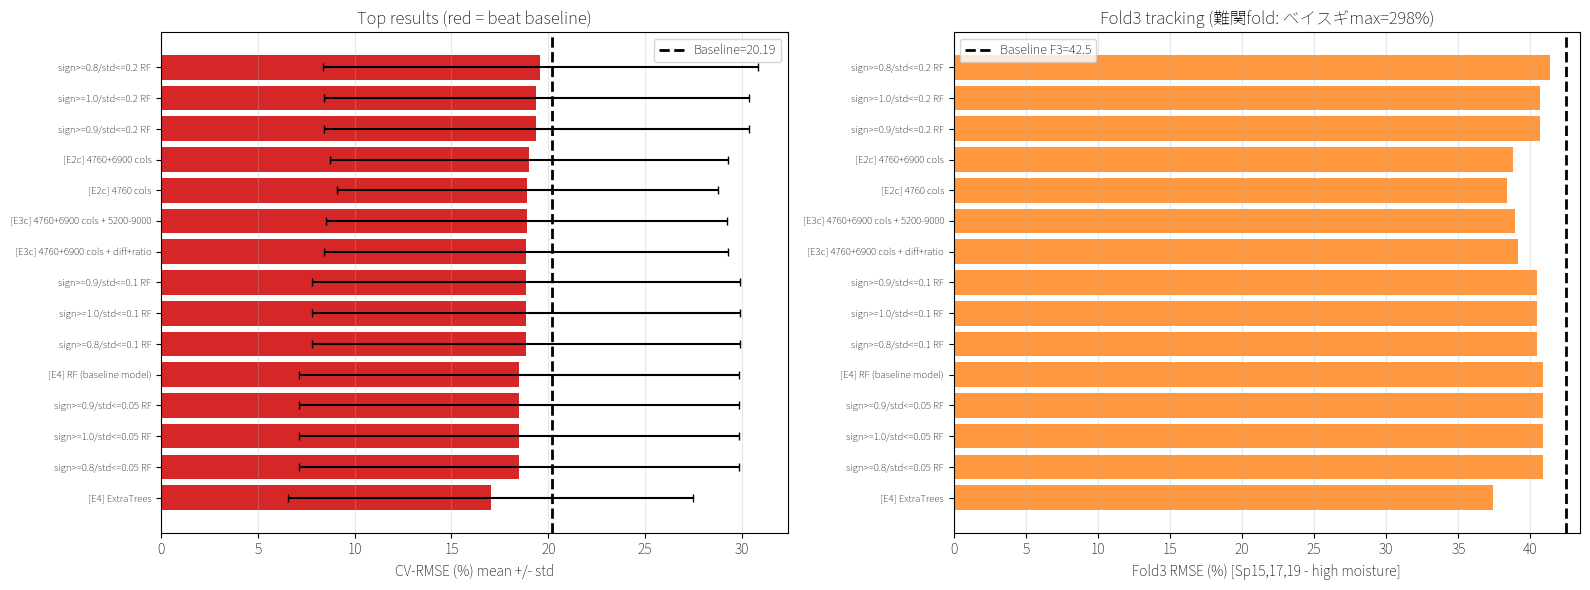

Saved: ../results/exp08_summary.png


In [7]:
df_res = pd.DataFrame(ROWS).sort_values("mean").reset_index(drop=True)
print("=" * 80)
print("SUMMARY: 全実験 (GroupKFold, 元スケールRMSE, baseline=20.19%)")
print("=" * 80)
print(df_res[["name","n_feat","mean","std","F1","F2","F3","F4","F5","diff"]].to_string(index=False))

best = df_res.iloc[0]
print()
if best["diff"] < 0:
    print(f"ベースライン(20.19%)超え: {best['name']}  RMSE={best['mean']:.2f}%  "
          f"改善={-best['diff']:.2f}pp")
else:
    print(f"ベースライン未超え. 最良: {best['name']}  RMSE={best['mean']:.2f}%  "
          f"差={best['diff']:+.2f}pp")

# Bar chart
top_n = min(15, len(df_res))
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
d = df_res.head(top_n)

# Mean RMSE
colors = ["#d62728" if v < 0 else "#aec7e8" for v in d["diff"]]
axes[0].barh(range(top_n), d["mean"], color=colors, xerr=d["std"], capsize=3)
axes[0].axvline(BASELINE_MEAN, color="black", lw=2, ls="--", label=f"Baseline={BASELINE_MEAN}")
axes[0].set_yticks(range(top_n))
axes[0].set_yticklabels(d["name"], fontsize=7)
axes[0].set_xlabel("CV-RMSE (%) mean +/- std")
axes[0].set_title("Top results (red = beat baseline)")
axes[0].legend(fontsize=9)
axes[0].grid(True, alpha=0.3, axis="x")

# Fold3 (hard fold)
d_f3 = d.copy()
d_f3["F3"] = d_f3["F3"].astype(float)
axes[1].barh(range(top_n), d_f3["F3"], color="#ff7f0e", alpha=0.8)
axes[1].axvline(42.5, color="black", lw=2, ls="--", label="Baseline F3=42.5")
axes[1].set_yticks(range(top_n))
axes[1].set_yticklabels(d_f3["name"], fontsize=7)
axes[1].set_xlabel("Fold3 RMSE (%) [Sp15,17,19 - high moisture]")
axes[1].set_title("Fold3 tracking (難関fold: ベイスギmax=298%)")
axes[1].legend(fontsize=9)
axes[1].grid(True, alpha=0.3, axis="x")

plt.tight_layout()
plt.savefig("../results/exp08_summary.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: ../results/exp08_summary.png")

## 総括（実行後に記入）

### 20.19%を破れたか
- TODO: セルの出力から記入

### 最も効いた特徴設計
- TODO

### 次に詰めるべき方向
1. **Fold3（高含水・ベイスギ sp15）対策** が依然として最重要課題
2. TODO